# Week of 2025.2.3 Experiments

Fred added a new advection state variable to the quail repo in two commits. 

1. The [first commit](https://github.com/fredriclam/quail_volcano/commit/6dc65a07eb42382739cb9cc30b65042b2ad800b0) implements the new conserved variable, and set up a simulation with the new variable in a 1D domain with rigid walls on both ends, and no source terms. 
2. The [second commit](https://github.com/fredriclam/quail_volcano/commit/335dc5ef3037e995e8a9c788fdaa0cac289bb0f4) implements a new placeholder source term that does nothing (except calculating pressure, temperature, etc. and making them available for further calculations), and source terms to the input file

As a first step, I worked off Fred's branch to set up a [steady state flow simulation](https://paxtonsc.github.io/files/geophysics/2025.1.28.experiments.html) where I was able to calculate the velocity of the flow based on conservation of momentum. 

As a next step, I am going to begin manipulating the new advection quantity and use the method of characteristics to verify that the new quantity is correctly implemented. 

First, let's make sure all our imports are set up so we can plot the steady state flow example I was previously working with. 

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Modify base path for depending on your file structure.
BASE_PATH = "/Users/paxton/git"

# Specify path where .pkl files are located
target_dir = f"{BASE_PATH}/quail_volcano/scenarios/simple_1D_test"
# Specify path for Quail source code
source_dir = f"{BASE_PATH}/quail_volcano/src"
# Change to working directory
os.chdir(target_dir)


# Import quail modules
os.chdir(source_dir)

import meshing.tools as mesh_tools

import numerics.helpers.helpers as helpers
import numerics.timestepping.tools as stepper_tools

import physics.zerodimensional.zerodimensional as zerod
import physics.euler.euler as euler
import physics.navierstokes.navierstokes as navierstokes
import physics.scalar.scalar as scalar
import physics.chemistry.chemistry as chemistry
import physics.multiphasevpT.multiphasevpT as multiphasevpT

import processing.readwritedatafiles as readwritedatafiles
import processing.post as post
import processing.plot as plot
import processing.animate as animate

import solver.DG as DG
import solver.ADERDG as ADERDG
import solver.tools as solver_tools

import time
from IPython.display import HTML
import multiprocessing as mp  
from multidomain import Domain, Observer

os.chdir(target_dir)

## 1. Review the current state of our system
To start out with, I update the animation of our system to include the new state variable `arhoX` implemented by Fred. We can see it is encoded as `pDensityX` in our state indices. 

In [2]:
solver = readwritedatafiles.read_data_file(f"steady_state_flow/test_output_0.pkl")
physics = solver.physics
physics.state_indices

{'pDensityA': 0,
 'pDensityWv': 1,
 'pDensityM': 2,
 'XMomentum': 3,
 'Energy': 4,
 'pDensityWt': 5,
 'pDensityC': 6,
 'pDensityFm': 7,
 'pDensityX': 8}

In the original configuration, the `arhoX` term is $0$ for all $(x, t)$.

As an initial experiment, I modified the initial conditions so the new state variable is set as function of position:

`arhoX =  1+ np.cos(x/100)`

I am surprised that the solution is not affected by the velocity of the fluid system. 

In [3]:
ani = animate.animate_conduit_pressure("steady_state_flow", iterations=100, file_prefix="test_output")

HTML(ani.to_html5_video())

/Users/paxton/git/quail_volcano/scenarios/simple_1D_test


## 2. Characteristic curves 

The advection equation can be written as: 

$$ \frac{\partial q}{\partial t} + u \frac{\partial q}{\partial x} = S$$

Applying the method of characteristics, we observe that:

$\frac{\partial q}{\partial t} = S$ along the curve $\frac{dx}{dt} = u$

That implies that our solution is of the form:

$$
q(x, t) = st + f(x-ut)
$$

What surprises me, is that after modifying the initial conditions, my solution is not constant along the $x - ut$ characteristic lines as I would expect. 

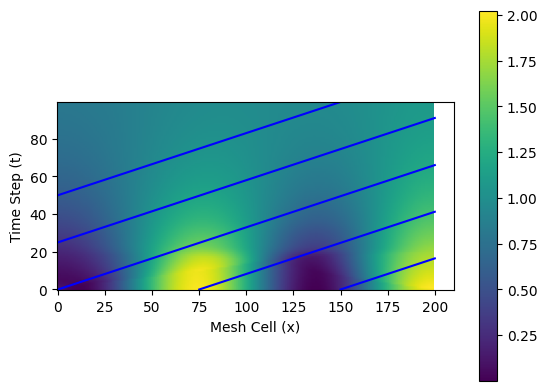

In [7]:
folder = "steady_state_flow"
file_prefix = "test_output"

X = np.zeros((100, 200)) # 100 time steps, 200 mesh cells

for i in range(0, 100):
    solver = readwritedatafiles.read_data_file(f"{folder}/{file_prefix}_{i}.pkl")
    arhoX = solver.state_coeffs[:,:,solver.physics.get_state_index("pDensityX")]

    X[i, :] = arhoX.ravel()

plt.imshow(X)

u = 0.33

# Plot the charecteristics we expect the solution to be constant along. 
plt.plot([0, 150], [50, 150*u+50], color='b')
plt.plot([0, 200], [25, 200*u+25], color='b')
plt.plot([0, 200], [0, 200*u], color='b')
plt.plot([75, 200], [0, 125*u], color='b')
plt.plot([150, 200], [0, 50*u], color='b')

plt.colorbar()
plt.ylabel('Time Step (t)')
plt.xlabel('Mesh Cell (x)')
plt.gca().invert_yaxis()
plt.title("New state variable (pDensityX) over time and space")